<a href="https://colab.research.google.com/github/regmiresearch/ImageProcessingProjects/blob/main/Chapter17/SDXL-Turbo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
%pip -q install diffusers accelerate torch-snippets torchinfo lovely_tensors

In [2]:
from diffusers import DiffusionPipeline
import torch

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
# Define the Stable Diffusion XL pipeline
pipeline = DiffusionPipeline.from_pretrained( "stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16, )
# Set the device for the pipeline
pipeline = pipeline.to("cuda")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


CPU times: user 25.2 s, sys: 15.4 s, total: 40.6 s
Wall time: 42.1 s


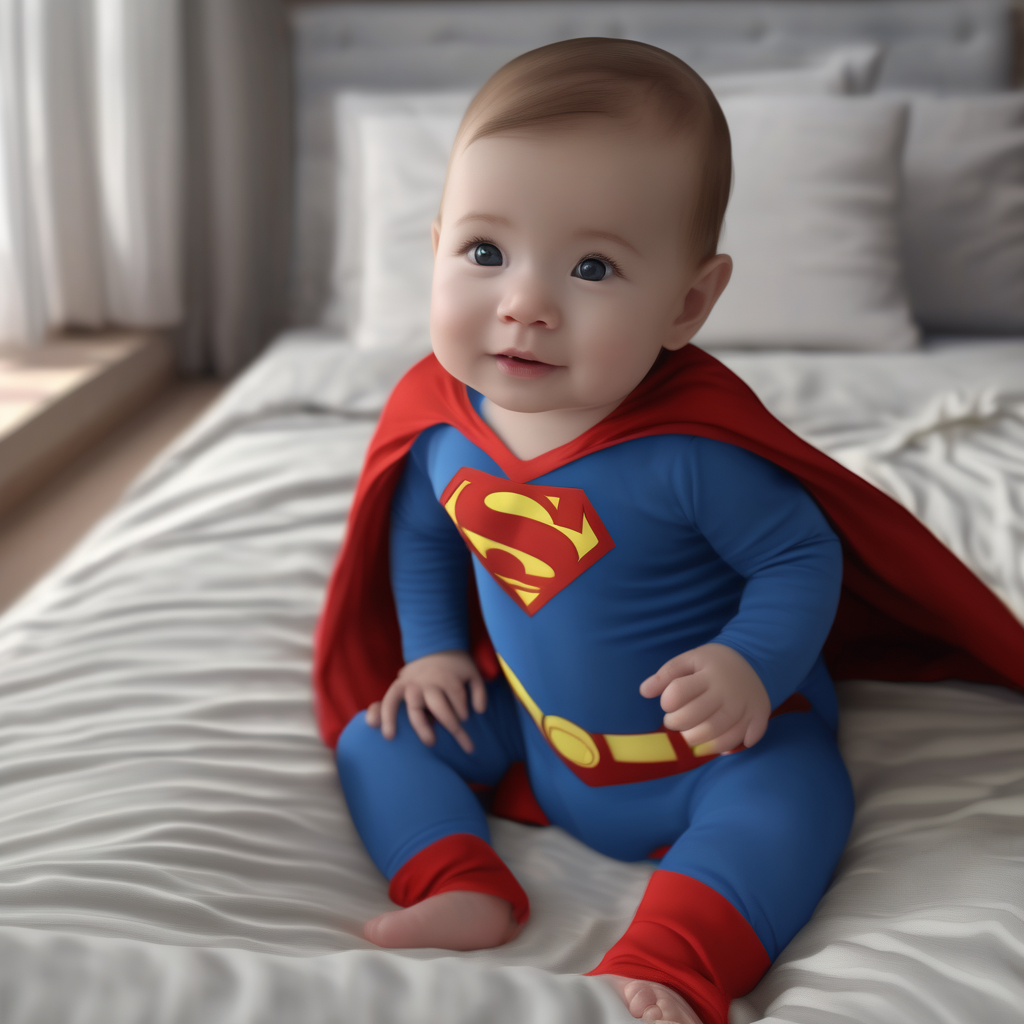

In [4]:
%%time
generator = torch.Generator(device="cuda").manual_seed(42)
prompt = "baby in superman dress, photorealistic, cinematic"
n_prompt = 'bad, ugly'

image = pipeline(prompt, guidance_scale=7.0, negative_prompt = n_prompt).images[0]
image

In [5]:
image.size

(1024, 1024)

In [6]:
from torchinfo import summary
summary(pipeline.unet)

Layer (type:depth-idx)                                            Param #
UNet2DConditionModel                                              --
├─Conv2d: 1-1                                                     11,840
├─Timesteps: 1-2                                                  --
├─TimestepEmbedding: 1-3                                          --
│    └─Linear: 2-1                                                410,880
│    └─SiLU: 2-2                                                  --
│    └─Linear: 2-3                                                1,639,680
├─Timesteps: 1-4                                                  --
├─TimestepEmbedding: 1-5                                          --
│    └─Linear: 2-4                                                3,605,760
│    └─SiLU: 2-5                                                  --
│    └─Linear: 2-6                                                1,639,680
├─ModuleList: 1-6                                                 --

In [7]:
from torch_snippets.trainer.hooks import print_module_ios_for

with print_module_ios_for(pipeline.unet, {'DownBlock2D', 'CrossAttnDownBlock2D', 'CrossAttnUpBlock2D', 'UpBlock2D'}):
  image = pipeline(prompt, num_inference_steps = 1, guidance_scale=0.0, negative_prompt = n_prompt).images[0]

  0%|          | 0/1 [00:00<?, ?it/s]

══════════════════════════════════════════════════════════════════
Module Name: DownBlock2D. Child Name: down_blocks.0
Input Kwargs: 
  hidden_states - 🔦tensor[1, 320, 128, 128] f16 n=5242880 (10 MiB) x∈[-3.982 | ▁▁▁▇█▁▁▁ | 3.924] μ=0.013 σ=0.489 cuda:0 - ID:#3565c4d1
  temb - 🔦tensor[1, 1280] f16 2.50 KiB x∈[-3.730 |▁▁▁▃█▁▁ ▁▁| 5.266] μ=-0.128 σ=0.469 cuda:0 - ID:#cf4bf04b

Input Args:

Outputs: 
  1 - 🔦tensor[1, 320, 64, 64] f16 n=1310720 (2.50 MiB) x∈[-12.219 | ▁▁▁▇█▂▁▁ | 11.445] μ=-0.114 σ=1.737 cuda:0 - ID:#1e90e82d
  2()
    0 - 🔦tensor[1, 320, 128, 128] f16 n=5242880 (10 MiB) x∈[-5.875 | ▁▁▁▁█▆▁▁▁| 4.094] μ=-0.053 σ=0.559 cuda:0 - ID:#f9fce02a
    1 - 🔦tensor[1, 320, 128, 128] f16 n=5242880 (10 MiB) x∈[-7.504 |  ▁▁▂█▁▁  | 6.148] μ=-0.069 σ=0.625 cuda:0 - ID:#607d604f
    2 - 🔦tensor[1, 320, 64, 64] f16 n=1310720 (2.50 MiB) x∈[-12.219 | ▁▁▁▇█▂▁▁ | 11.445] μ=-0.114 σ=1.737 cuda:0 - ID:#1e90e82d

══════════════════════════════════════════════════════════════════
═══════════════════

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


In [8]:
from diffusers import AutoPipelineForText2Image, AutoPipelineForImage2Image
import torch

pipeline = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
pipeline = pipeline.to("cuda")

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

CPU times: user 782 ms, sys: 26.8 ms, total: 809 ms
Wall time: 1.42 s


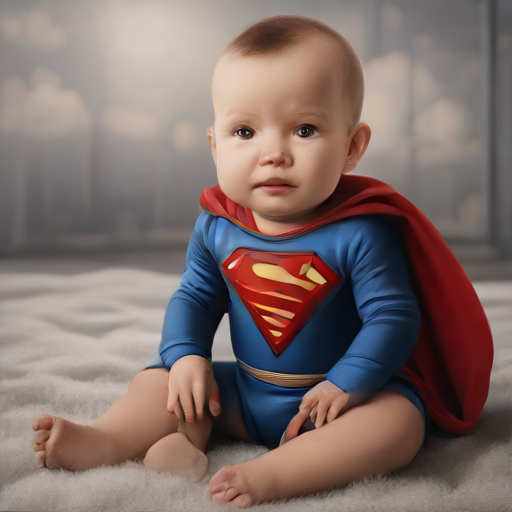

In [9]:
%%time
prompt = "baby in superman dress, photorealistic, cinematic"
n_prompt = 'bad, ugly, blur, deformed'

image = pipeline(prompt, num_inference_steps = 1, guidance_scale=0.0, negative_prompt = n_prompt, seed = 42).images[0]
image

In [10]:
from torchinfo import summary
summary(pipeline.unet)

Layer (type:depth-idx)                                            Param #
UNet2DConditionModel                                              --
├─Conv2d: 1-1                                                     11,840
├─Timesteps: 1-2                                                  --
├─TimestepEmbedding: 1-3                                          --
│    └─Linear: 2-1                                                410,880
│    └─SiLU: 2-2                                                  --
│    └─Linear: 2-3                                                1,639,680
├─Timesteps: 1-4                                                  --
├─TimestepEmbedding: 1-5                                          --
│    └─Linear: 2-4                                                3,605,760
│    └─SiLU: 2-5                                                  --
│    └─Linear: 2-6                                                1,639,680
├─ModuleList: 1-6                                                 --

In [11]:
from torch_snippets.trainer.hooks import print_module_ios_for

with print_module_ios_for(pipeline.unet, {'DownBlock2D', 'CrossAttnDownBlock2D', 'CrossAttnUpBlock2D', 'UpBlock2D'}):
  image = pipeline(prompt, num_inference_steps = 1, guidance_scale=0.0, negative_prompt = n_prompt).images[0]


  0%|          | 0/1 [00:00<?, ?it/s]

══════════════════════════════════════════════════════════════════
Module Name: DownBlock2D. Child Name: down_blocks.0
Input Kwargs: 
  hidden_states - 🔦tensor[1, 320, 64, 64] f16 n=1310720 (2.50 MiB) x∈[-2.771 | ▁▁▃██▂▁▁▁| 2.881] μ=0.013 σ=0.490 cuda:0 - ID:#5e689f83
  temb - 🔦tensor[1, 1280] f16 2.50 KiB x∈[-2.918 |▁▁█▁▁▁▁▁▁▁| 7.727] μ=0.021 σ=0.677 cuda:0 - ID:#2c28bf2a

Input Args:

Outputs: 
  1 - 🔦tensor[1, 320, 32, 32] f16 n=327680 (640 KiB) x∈[-6.461 | ▁▁▂██▂▁▁▁| 6.410] μ=-0.012 σ=0.898 cuda:0 - ID:#c4731cee
  2()
    0 - 🔦tensor[1, 320, 64, 64] f16 n=1310720 (2.50 MiB) x∈[-4.477 | ▁▁▁▂██▁▁ | 3.127] μ=-0.052 σ=0.521 cuda:0 - ID:#19840882
    1 - 🔦tensor[1, 320, 64, 64] f16 n=1310720 (2.50 MiB) x∈[-4.500 |  ▁▁▁█▄▁▁ | 3.240] μ=-0.018 σ=0.361 cuda:0 - ID:#1eb7ef55
    2 - 🔦tensor[1, 320, 32, 32] f16 n=327680 (640 KiB) x∈[-6.461 | ▁▁▂██▂▁▁▁| 6.410] μ=-0.012 σ=0.898 cuda:0 - ID:#c4731cee

══════════════════════════════════════════════════════════════════
════════════════════════════